In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Veriyi Yükle
df = pd.read_csv('ai4i2020.csv')

# 2. Veri Temizleme (KNIME'da yaptığımız gibi ID'leri atıyoruz)
df_clean = df.drop(['UDI', 'Product ID', 'Type'], axis=1)

# 3. Normalizasyon (Ölçeklendirme)
# Anomali tespiti için verilerin aynı ölçekte olması şarttır
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# 4. AutoML Yaklaşımı: Isolation Forest ile Modelleme
# contamination: Verideki tahmini anomali oranı (0.05 = %5)
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(df_scaled)

# 5. Skorları ve Kararları Hesapla
# -1 anomali, 1 normal demektir
df_clean['Anomaly_Score'] = model.decision_function(df_scaled)
df_clean['Anomaly'] = model.predict(df_scaled)
df_clean['Anomaly_Label'] = df_clean['Anomaly'].map({1: 'Normal', -1: 'Anomali'})

print("--- Anomali Tespiti Sonuç Özeti ---")
print(df_clean['Anomaly_Label'].value_counts())

C:\Users\ibrah\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ibrah\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


--- Anomali Tespiti Sonuç Özeti ---
Anomaly_Label
Normal     9500
Anomali     500
Name: count, dtype: int64


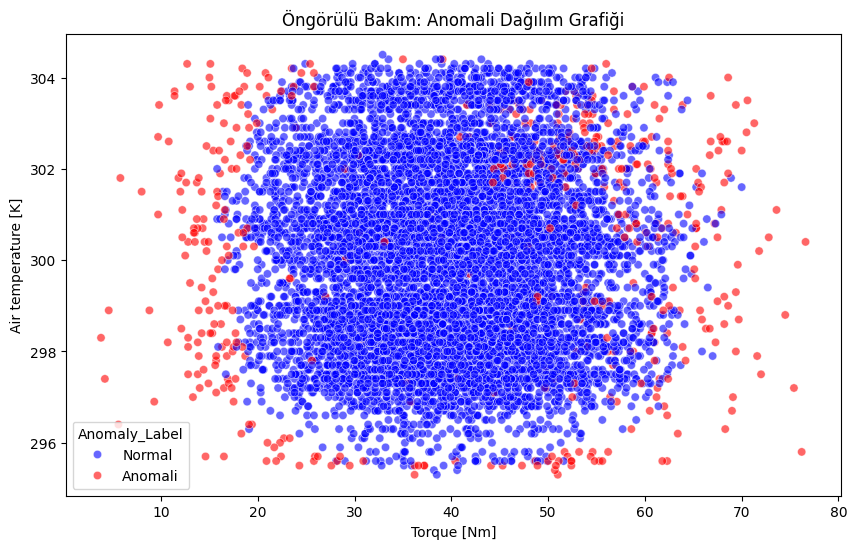

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Torque [Nm]', y='Air temperature [K]', 
                hue='Anomaly_Label', palette={'Normal': 'blue', 'Anomali': 'red'}, alpha=0.6)
plt.title('Öngörülü Bakım: Anomali Dağılım Grafiği')
plt.show()